
=== Solenoid Length = 2000 mm ===
  900/900  (100%)
2-D meshgrid (A-scan) computed.
  Valid cells     : 900 / 900
  Converged cells : 900 / 900
  Ri              : 50.0 – 1500.0 mm
  A_total (mm²)   : 18862.1 – 4272566.0
  f_sc (%)        : 16.0 – 100.0
  Len SC (km)     : 43.3 – 11174.3
  B0              : 1.585 – 143.266 T
  Stress          : 203.7 – 750.0 MPa
Saved raw grids -> area_grids_L2000mm.csv  (900 cells)
  [!] Magnet CSV not found: magnet_characteristics.csv


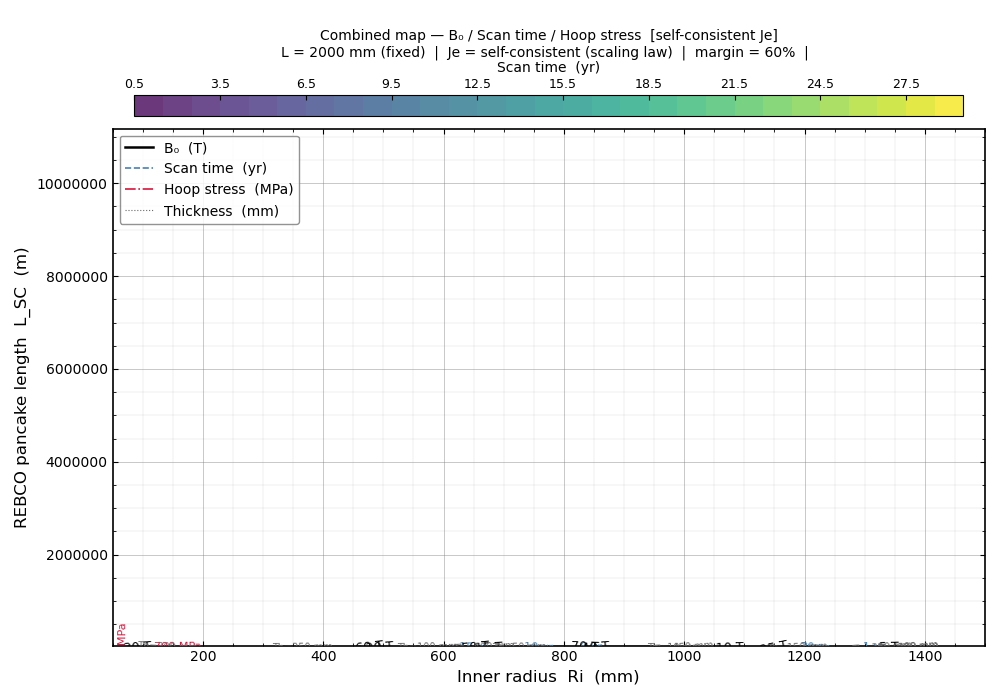

  [!] Magnet CSV not found: magnet_characteristics.csv


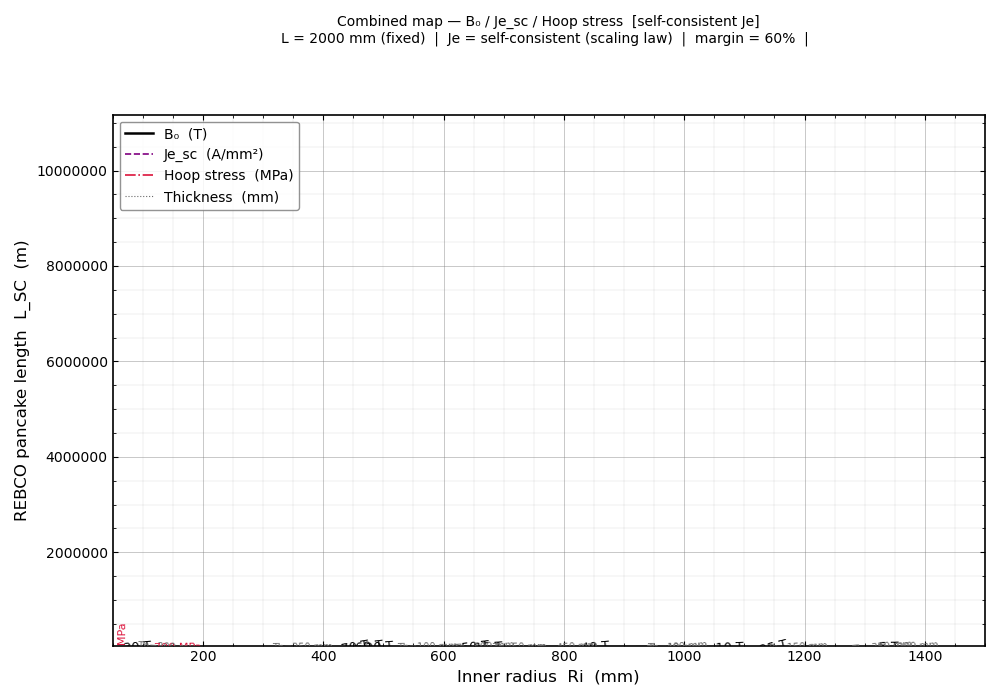

  [!] Magnet CSV not found: magnet_characteristics.csv


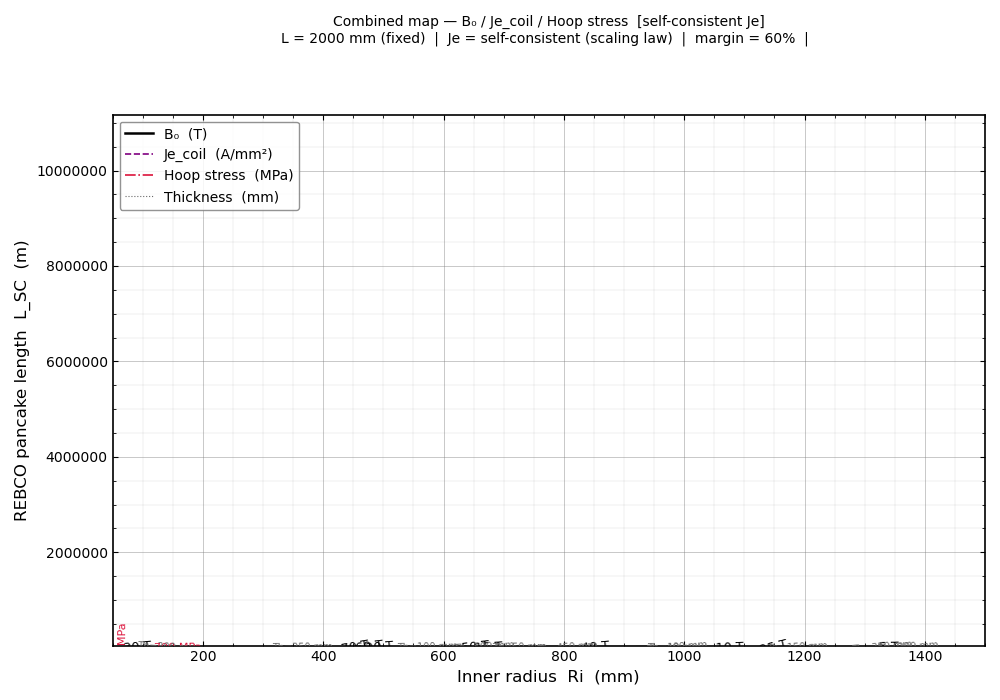


=== Solenoid Length = 5000 mm ===


In [ ]:
# main.py
# ─────────────────────────────────────────────────────────────────────────────
# Orchestrates the full solenoid design-space study.
#
#   Run in Jupyter/IPython to utilize interactive widgets.
# ─────────────────────────────────────────────────────────────────────────────
%matplotlib widget

import importlib
import numpy as np

# Hot-reload local modules to ensure we always have the latest code
import solenoid_lib
importlib.reload(solenoid_lib)

import config
importlib.reload(config)

import grid
importlib.reload(grid)

import io_grids
importlib.reload(io_grids)

import plots_thickness
importlib.reload(plots_thickness)

import plots_area
importlib.reload(plots_area)


# Define the lengths (in meters) to iterate over
LENGTHS_M =  [2.0, 5.0, 10.0]  

def main():
    all_grids = {}
    
    for L in LENGTHS_M:
        print(f"\n=== Solenoid Length = {L*1e3:.0f} mm ===")
        
        # 1. Update the physics library with the current length
        solenoid_lib.solenoid_length = L
        label = f"L{int(L*1e3)}mm"
        
        # 2. Build the meshgrids based on Area
        a_grids = grid.build_area_grid()
        
        # 3. Save the results to the newly formatted CSV
        csv_filename = f"area_grids_{label}.csv"
        io_grids.save_grids_long(a_grids, csv_filename, solenoid_length=L)
        
        # 4. Generate all the requested contour plots
        plots_area.plot_all(a_grids, label=label, solenoid_length_m=L)
        
        # Store for return
        all_grids[L] = a_grids
        
    return all_grids


if __name__ == "__main__":
    # Run the main loop
    all_grids = main()


Loading files:
  ./area_grids_L10000mm.csv
  ./area_grids_L2000mm.csv
  ./area_grids_L5000mm.csv
1847 / 2700 points kept after filtering


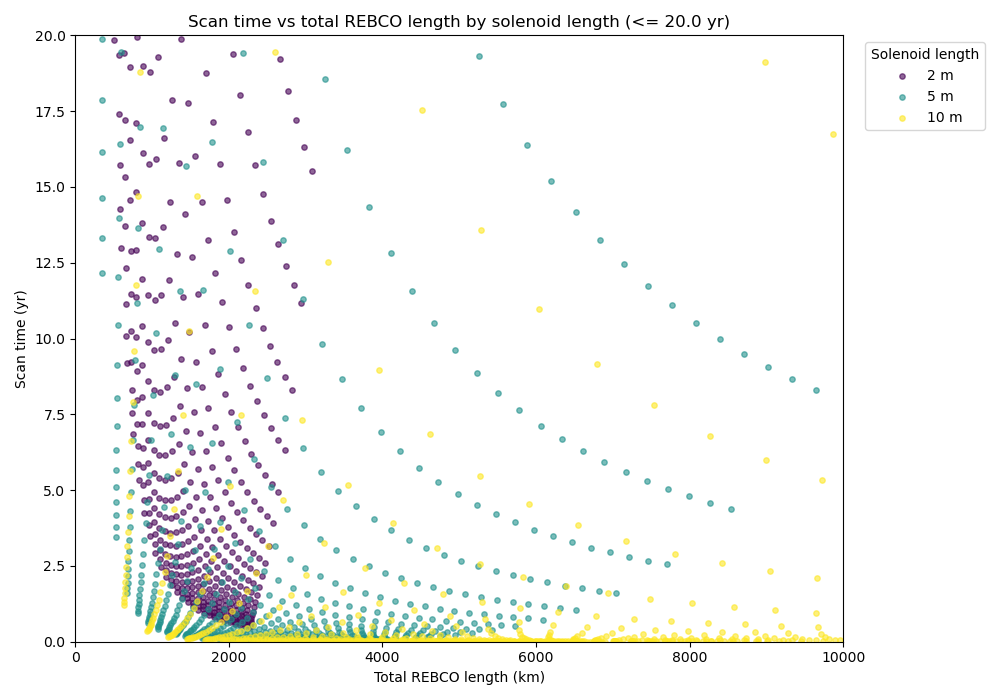

25 rows found with scan == 1.0 yr
Saved to ./magnets_scan_1yr.csv


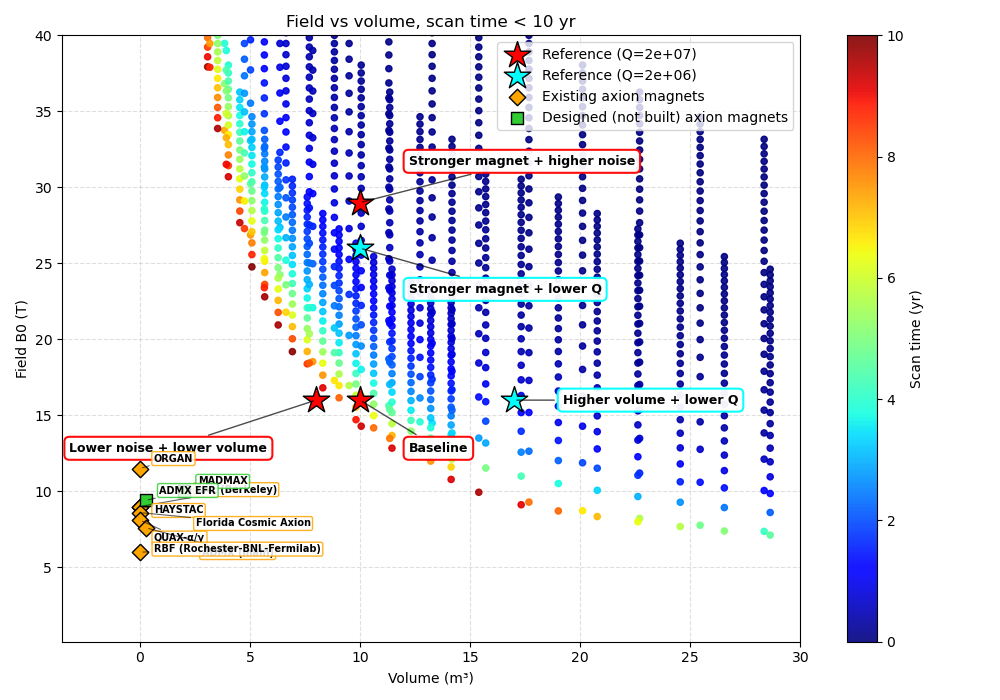

In [94]:
%matplotlib widget

import glob
import re
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# %%
DATA_DIR = '.'
OUT_DIR = '.'
SCAN_MAX_YEARS = 20.0   # cut off anything above this

# Axis limits -- set to None to auto-scale on that bound
X_MIN, X_MAX = 0, 10000   # total REBCO length (km)
Y_MIN, Y_MAX = 0, 20      # scan time (yr)

# Volume and Field axis limits for the second plot
V_MIN, V_MAX = None, 30     
B0_MIN, B0_MAX = None, 40   

# %%
def load_all_grids(data_dir):
    files = sorted(glob.glob(f'{data_dir}/area_grids_L*mm.csv'))
    if not files:
        sys.exit(f'No files matching area_grids_L*mm.csv found in {data_dir}')

    print('Loading files:')
    dfs = []
    for f in files:
        print(' ', f)
        d = pd.read_csv(f)
        
        # We no longer need the rename map because io_grids.py saves the exact names!
        
        # Extract solenoid length from filename if it happens to be missing
        match = re.search(r'L(\d+)mm', f)
        if match and 'solenoid_length_m' not in d.columns:
            d['solenoid_length_m'] = int(match.group(1)) / 1000.0
            
        dfs.append(d)

    return pd.concat(dfs, ignore_index=True)


df_all = load_all_grids(DATA_DIR)

# %%
# Filter: keep physical points, scan time within range
df_ok = df_all[(df_all['scan'] > 0) & (df_all['scan'] <= SCAN_MAX_YEARS)].copy()

if 'converged' in df_ok.columns:
    df_ok = df_ok[df_ok['converged'].astype(bool)]

print(f'{len(df_ok)} / {len(df_all)} points kept after filtering')

# %%
# Plot 1: scan time vs total REBCO length, colored by solenoid length
fig, ax = plt.subplots(figsize=(10, 7))

lengths = sorted(df_ok['solenoid_length_m'].unique())
cmap = plt.get_cmap('viridis', len(lengths))

scatters = []
for i, L in enumerate(lengths):
    sub = df_ok[df_ok['solenoid_length_m'] == L].reset_index(drop=True)
    
    x_data = sub['length_sc'] / 1000
    y_data = sub['scan']
    
    sc = ax.scatter(x_data, y_data,
                     color=cmap(i), s=15, alpha=0.6, label=f'{L:.0f} m',
                     picker=True, pickradius=5)
    scatters.append((sc, sub))

ax.set_xlabel('Total REBCO length (km)')
ax.set_ylabel('Scan time (yr)')
ax.set_title(f'Scan time vs total REBCO length by solenoid length (<= {SCAN_MAX_YEARS} yr)')
ax.legend(title='Solenoid length', bbox_to_anchor=(1.02, 1), loc='upper left')

ax.set_xlim(left=X_MIN, right=X_MAX)
ax.set_ylim(bottom=Y_MIN, top=Y_MAX)

fig.tight_layout()

# Set up the annotation box for the click event
annot = ax.annotate("", xy=(0, 0), xytext=(15, 15), textcoords="offset points",
                     bbox=dict(boxstyle="round", fc="w"), fontsize=9)
annot.set_visible(False)

def on_pick(event):
    sc_obj = event.artist
    ind = event.ind[0]
    for sc, sub in scatters:
        if sc is sc_obj:
            row = sub.iloc[ind]
            break

    x = row['length_sc'] / 1000
    y = row['scan']
    
    # Text formatting using the exact variables from your grid solver
    text = (f"L={row['solenoid_length_m']:.1f} m\n"
            f"Ri={row['ri']:.3f} m, Th={row['th']:.3f} m\n"
            f"B0={row['b0']:.2f} T\n"
            f"stress={row['stress']:.1f} MPa\n"
            f"Je_coil={row['je_coil']:.0f}, Je_sc={row['je_sc']:.0f} A/mm² (f_sc={row['f_sc']*100:.1f}%)\n"
            f"total_length={x:.1f} km")

    annot.xy = (x, y)
    annot.set_text(text)
    annot.set_visible(True)
    fig.canvas.draw_idle()

fig.canvas.mpl_connect('pick_event', on_pick)

outfile = f'{OUT_DIR}/scan_vs_rebcolength_by_L.png'
fig.savefig(outfile, dpi=150)

plt.show()

# %%
# Select rows with scan time == 1 year and save to CSV
TARGET_SCAN = 1.0
TOL = 0.05  # tolerance for floating-point comparison

df_scan1 = df_ok[np.isclose(df_ok['scan'], TARGET_SCAN, atol=TOL)].copy()

print(f'{len(df_scan1)} rows found with scan == {TARGET_SCAN} yr')

outfile_csv = f'{OUT_DIR}/magnets_scan_1yr.csv'
df_scan1.to_csv(outfile_csv, index=False)
print(f'Saved to {outfile_csv}')

# %%
# Plot 2: Field vs Volume, colored by scan time (< 10 yr)
df_vol_field = df_ok[df_ok['scan'] < 10].copy().reset_index(drop=True)

fig2, ax2 = plt.subplots(figsize=(10, 7))

# Added picker=True and pickradius=5 here
sc2 = ax2.scatter(df_vol_field['v'], df_vol_field['b0'],
                  c=df_vol_field['scan'], cmap='jet', vmin=0, vmax=10, 
                  s=20, alpha=0.9, zorder=2,
                  picker=True, pickradius=5)

cbar = fig2.colorbar(sc2, ax=ax2)
cbar.set_label('Scan time (yr)')

# === Reference Points ===
ref_points = [
    (16, 10, 20e6, -20, 6.2,  'Baseline',                       ( 35, -30), 'left',  'top'),
    (29, 10, 20e6, -5,  3.2,  'Stronger magnet + higher noise', ( 35,  25), 'left',  'bottom'),
    (16,  8, 20e6, -25, 7.3,  'Lower noise + lower volume',     (-35, -30), 'right', 'top'),
    (16, 17,  2e6, -20, 10.6, 'Higher volume + lower Q',        ( 35,   0), 'left',  'center'),
    (26, 10,  2e6, -20, 8.9,  'Stronger magnet + lower Q',      ( 35, -25), 'left',  'top')
]

plotted_qs = set()
q_colors = {20e6: 'red', 2e6: 'cyan'}

for B0, V_m3, Q, eta_dB, expected, name, offset, ha, va in ref_points:
    color = q_colors.get(Q, 'magenta')
    label = f'Reference (Q={Q:.0e})' if Q not in plotted_qs else ""
    plotted_qs.add(Q)
    
    ax2.scatter(V_m3, B0, marker='*', s=400, c=color, edgecolors='black', 
                zorder=5, label=label)
    
    ax2.annotate(name, (V_m3, B0), 
                 xytext=offset, textcoords='offset points',
                 ha=ha, va=va,
                 fontsize=9, fontweight='bold', zorder=6,
                 bbox=dict(boxstyle="round,pad=0.4", fc="white", ec=color, lw=1.5, alpha=0.95),
                 arrowprops=dict(arrowstyle="-", color='black', lw=1.0, alpha=0.7))

# === Existing Axion Magnets ===
existing_magnets = [
    ('ORGAN',                        11.5, 0.000048, (10,   5)),
    ('CAL (Berkeley)',                9.0, 0.007,    (40,  10)),
    ('HAYSTAC',                       9.0, 0.002,    (10,  -5)),
    ('Florida Cosmic Axion',          8.6, 0.008,    (40, -10)),
    ('QUAX-α/γ',                      8.1, 0.0088,   (10, -15)),
    ('ADMX (main)',                   7.6, 0.2827,   (40, -20)),
    ('RBF (Rochester-BNL-Fermilab)',  6.0, 0.011,    (10,   0))
]

ex_V = [m[2] for m in existing_magnets]
ex_B = [m[1] for m in existing_magnets]
ax2.scatter(ex_V, ex_B, marker='D', s=70, c='orange', edgecolors='black', 
            zorder=4, label='Existing axion magnets')

for name, B0, V, offset in existing_magnets:
    ax2.annotate(name, (V, B0), 
                 xytext=offset, textcoords='offset points',
                 fontsize=7, fontweight='bold', zorder=6,
                 bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="orange", lw=1.0, alpha=0.85),
                 arrowprops=dict(arrowstyle="-", color='black', lw=0.8, alpha=0.6))

# === Designed (Not Built) Axion Magnets ===
designed_magnets = [
    ('MADMAX',     10.0, 2.0,   (10,  5)),
    ('ADMX EFR',    9.4, 0.258, (10,  5))
]

ds_V = [m[2] for m in designed_magnets]
ds_B = [m[1] for m in designed_magnets]
ax2.scatter(ds_V, ds_B, marker='s', s=70, c='limegreen', edgecolors='black', 
            zorder=4, label='Designed (not built) axion magnets')

for name, B0, V, offset in designed_magnets:
    ax2.annotate(name, (V, B0), 
                 xytext=offset, textcoords='offset points',
                 fontsize=7, fontweight='bold', zorder=6,
                 bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="limegreen", lw=1.0, alpha=0.85),
                 arrowprops=dict(arrowstyle="-", color='black', lw=0.8, alpha=0.6))

ax2.set_xlabel('Volume (m³)')
ax2.set_ylabel('Field B0 (T)')
ax2.set_title('Field vs volume, scan time < 10 yr')
ax2.legend(loc='upper right')
ax2.grid(True, linestyle='--', alpha=0.4, zorder=1)
ax2.set_xlim(left=V_MIN, right=V_MAX)
ax2.set_ylim(bottom=B0_MIN, top=B0_MAX)
fig2.tight_layout()

# === Added Interactive Event Logic for Figure 2 ===
annot2 = ax2.annotate("", xy=(0, 0), xytext=(15, 15), textcoords="offset points",
                      bbox=dict(boxstyle="round", fc="w"), fontsize=9, zorder=10)
annot2.set_visible(False)

def on_pick2(event):
    if event.artist != sc2:
        return
        
    ind = event.ind[0]
    row = df_vol_field.iloc[ind]
    
    x = row['v']
    y = row['b0']
    
    # Check if length_sc_km exists, otherwise calculate it from length_sc
    sc_km = row['length_sc_km'] if 'length_sc_km' in row else row['length_sc'] / 1000
    
    text = (f"L={row['solenoid_length_m']:.1f} m\n"
            f"Ri={row['ri']:.3f} m\n"
            f"V={x:.2f} m³\n"
            f"B0={y:.2f} T\n"
            f"Scan={row['scan']:.2f} yr\n"
            f"length_sc_km={sc_km:.1f}\n"
            f"pancake_length_m={row['pancake_length_m']:.1f}")

    annot2.xy = (x, y)
    annot2.set_text(text)
    annot2.set_visible(True)
    fig2.canvas.draw_idle()

fig2.canvas.mpl_connect('pick_event', on_pick2)
# ===================================================

outfile2 = f'{OUT_DIR}/field_vs_volume_scan_lt_10yr.png'
fig2.savefig(outfile2, dpi=150)

plt.show()

In [34]:
import importlib
import math
import solenoid_lib


importlib.reload(solenoid_lib)


from solenoid_lib import scan_time, dB_to_eta

# Magnet / bore geometry
B0_baseline = 18          # T
l_bore      = 8.5         # m
d_bore      = 0.090       # m
V_m3        = math.pi * (d_bore / 2)**2 * l_bore   # bore volume [m^3]
print(f"Bore volume: {V_m3:.4f} m^3")

s_per_year = 365.25 * 24 * 3600


print(f"{'Scenario':<40} {'Expected':>10}  {'DFSZ':>10} {'Ratio':>10}")
print("-" * 74)

scenarios = [
    (16, 10, 20e6, -20, 6.2,  'Baseline'),
    (29, 10, 20e6, -5,  3.2,  'Stronger magnet + higher noise'),
    (16,  8, 20e6, -25, 7.3,  'Lower noise + lower volume'),
    (16, 17,  2e6, -20, 10.6, 'Higher volume + lower Q'),
    (26, 10,  2e6, -20, 8.9,  'Stronger magnet + lower Q'),
    (B0_baseline, V_m3, 20e6, -20, 2.24,  'CORE-GUT')
]

for (B0, V_m3, Q, eta_dB, expected, name) in scenarios:
    eta_A  = dB_to_eta(eta_dB)
    t_dfsz = scan_time(B0, V_m3, Q=Q, eta_A=eta_A, model='DFSZ')
    ratio  = expected / t_dfsz
    print(f"{name:<40} {expected:>10.1f} {t_dfsz:>10.2f} {ratio:>10.3f}")

Bore volume: 0.0541 m^3
Scenario                                   Expected        DFSZ      Ratio
--------------------------------------------------------------------------
Baseline                                        6.2       6.01      1.032
Stronger magnet + higher noise                  3.2       3.13      1.022
Lower noise + lower volume                      7.3       7.11      1.027
Higher volume + lower Q                        10.6      10.25      1.035
Stronger magnet + lower Q                       8.9       8.62      1.033
CORE-GUT                                        2.2 135146609.74      0.000
